In [1]:
# Hacky way of importing local code - 
# I cannot get the Jupyter kernel to recognize local modules with pixi ??
import os
import sys
path_to_add = os.path.abspath(os.path.join(os.getcwd(), '..')) 
sys.path.insert(0, path_to_add)

In [2]:
import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sat.revisit_times import (
    SATELLITES,
    compute_cumulative_full_coverage,
    get_satellite_params, 
    calculate_revisit_rate_dataframe
)

In [4]:
SPACETRACK_USER = os.getenv("SPACETRACK_USER")
SPACETRACK_PASS = os.getenv("SPACETRACK_PASS")

# Date range for revisit calculation
START = datetime.datetime(2025, 6, 1)
END = datetime.datetime(2025, 8, 31)

# Satellite list: Sentinel-1 IW swath (~250 km total width)
satlist = [
    "Landsat-8", "Landsat-9",
    "Sentinel-1A", "Sentinel-1C",
    "Sentinel-2A", "Sentinel-2B"
]

# Simulation timestep
TIMESTEP_S = 60  # seconds

# Regions (lon_min, lat_min, lon_max, lat_max) for H3 grid
REGIONS = {
    "Japan": (129., 31., 146., 46.),
#    "US": (-125.0, 24.0, -66.5, 49.5), 
#    "Australia": (112.0, -44.0, 154.0, -10.0),
#    "Europe": (-10.0, 34.0, 30.0, 70.5),
}

# H3 resolutions
RESOLUTIONS = [4,]

sats, swaths = get_satellite_params(satlist)

In [ ]:
res_data, full_events = compute_cumulative_full_coverage(
    SPACETRACK_USER,
    SPACETRACK_PASS,
    START,
    END,
    sats,
    REGIONS,
    TIMESTEP_S,
    swaths,
    RESOLUTIONS
)

timesteps:   1%|▌                                                               | 1252/131040 [00:18<29:20, 73.70it/s]

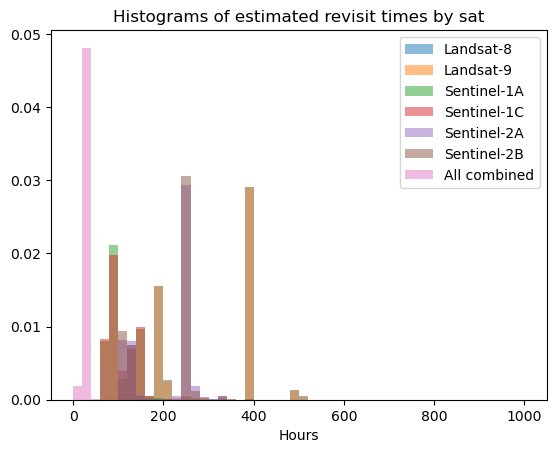

In [6]:
# plot histograms of revisit rates

fig, ax = plt.subplots()

for sat in revisit_df_separate.satellite.unique():
    ax.hist(
        revisit_df_separate[revisit_df_separate.satellite==sat].revisit_rate_hours,
        density=True, alpha=0.5, range=(0,1000), bins=50, label=sat
    )
    
ax.hist(revisit_df_combined.revisit_rate_hours, density=True, alpha=0.5, range=(0,1000), bins=50, label="All combined")

ax.legend()
ax.set_title("Histograms of estimated revisit times by sat")
ax.set_xlabel("Hours")
plt.show()

In [5]:
label = "r6_Japan_20250601_20250831"

revisit_df_separate = calculate_revisit_rate_dataframe(
    full_events, combine_satellites=False
)

revisit_df_combined = calculate_revisit_rate_dataframe(
    full_events, combine_satellites=True
)

/Users/katjensen/workspace/github/capturing_peak_flood_conditions_project/sat/revisit_times_v3.py:852: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  revisit_df = events_df.groupby(group_cols).apply(calculate_metrics)
/Users/katjensen/workspace/github/capturing_peak_flood_conditions_project/sat/revisit_times_v3.py:852: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  revisit_df = events_df.groupby(group_cols).apply(calcu

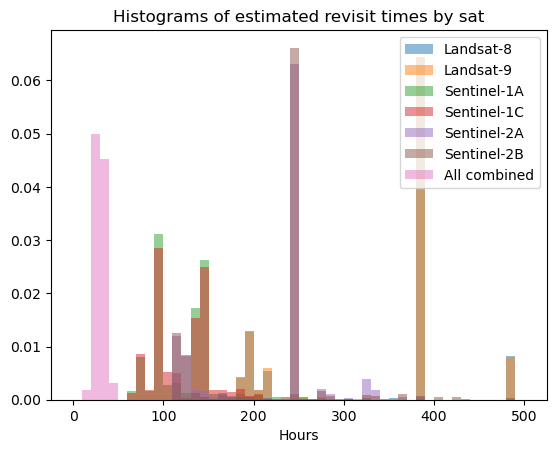

In [6]:
# plot histograms of revisit rates

fig, ax = plt.subplots()

for sat in revisit_df_separate.satellite.unique():
    ax.hist(
        revisit_df_separate[revisit_df_separate.satellite==sat].revisit_rate_hours,
        density=True, alpha=0.5, range=(0,500), bins=50, label=sat
    )
    
ax.hist(revisit_df_combined.revisit_rate_hours, density=True, alpha=0.5, range=(0,500), bins=50, label="All combined")

ax.legend()
ax.set_title("Histograms of estimated revisit times by sat")
ax.set_xlabel("Hours")
plt.show()

In [7]:
revisit_df_separate.groupby(["satellite", "revisit_rate_hours"]).size()

satellite    revisit_rate_hours
Landsat-8    189.344444             136
             189.346296             163
             189.827273            1860
             189.828788            3244
             192.000000            8384
                                   ... 
Sentinel-2B  336.000000               8
             336.003333             136
             360.000000              31
             384.000000             103
             420.004167               4
Length: 1365, dtype: int64

In [8]:
revisit_df_combined.groupby(["satellite", "revisit_rate_hours"]).size()

satellite    revisit_rate_hours
Landsat-8    18.163611             2
             18.471469             1
             18.629345             1
             19.119591             2
             19.288791             2
                                  ..
Sentinel-2B  39.230864             3
             39.396226             3
             39.971069             2
             40.153846             1
             41.538562             1
Length: 3651, dtype: int64

In [9]:
import json
from datetime import datetime

def save_full_coverage_events(events: dict, path: str) -> None:
    """Save full coverage event dictionary to a JSON file.

    Args:
        events (dict): Output dictionary from compute_cumulative_full_coverage().
            Keys are (satellite_name, h3_id) tuples.
            Values are lists of datetime objects marking full-coverage times.
        path (str): File path for output JSON.
    """
    serializable = {
        f"{sat}|{h3id}": [t.isoformat() for t in times]
        for (sat, h3id), times in events.items()
    }

    with open(path, "w") as f:
        json.dump(serializable, f, indent=2)

    print(f"[INFO] Saved {len(serializable)} coverage event entries to {path}")

def load_full_coverage_events(path: str) -> dict:
    """Load a full coverage events dictionary from JSON."""
    with open(path, "r") as f:
        data = json.load(f)

    return {
        tuple(k.split("|")): [datetime.fromisoformat(ts) for ts in v]
        for k, v in data.items()
    }

In [10]:
# write out

# event data
save_full_coverage_events(full_events, f"{label}_full_events.json")

# revist tables (each separate)
revisit_df_separate.to_csv(f"{label}_revisit_separate_satellites.csv", index=False)

# revisit table, combined
revisit_df_combined.to_csv(f"{label}_revisit_combined_satellites.csv", index=False)

[INFO] Saved 472740 coverage event entries to r6_Japan_20250601_20250831_full_events.json


In [11]:

import folium
from folium.plugins import MarkerCluster
import geopandas as gpd
from h3.api.basic_str import cell_to_boundary 
import matplotlib.cm as cm
import matplotlib.colors as colors
import pandas as pd
from shapely.geometry import Polygon


def h3_hex_polygon(hexid):
    """Generates a Shapely Polygon from an H3 index."""
    latlon = cell_to_boundary(hexid) 
    # The output is (lat, lon) tuples. We convert to (lon, lat) for Shapely.
    coords = [(lon, lat) for lat, lon in latlon]
    if coords[0] != coords[-1]:
        coords.append(coords[0])
    return Polygon(coords)

def create_revisit_geodataframe(revisit_df):
    """Converts the revisit DataFrame to a GeoDataFrame."""
    
    # 1. Add Geometry Column
    # Apply the h3_hex_polygon function to create the geometry
    revisit_df['geometry'] = revisit_df['h3_index'].apply(h3_hex_polygon)
    
    # 2. Convert to GeoDataFrame
    # Filter out NaNs in revisit_rate_hours before creating the GeoDataFrame
    gdf = gpd.GeoDataFrame(
        revisit_df.dropna(subset=['revisit_rate_hours']).copy(), 
        geometry='geometry', 
        crs="EPSG:4326"
    )
    return gdf
    
def visualize_revisit_rate(revisit_gdf, region_name="Japan"):
    """
    Creates an interactive Folium map to visualize the H3 grid, 
    colored by 'revisit_rate_hours'.
    """
    
    # Determine Map Center and Color Scale~
    
    # Use the bounding box of the data or a predefined center for the region
    if not revisit_gdf.empty:
        center_lat = revisit_gdf.geometry.centroid.y.mean()
        center_lon = revisit_gdf.geometry.centroid.x.mean()
    else:
        # Fallback to the center of Japan (from your REGIONS definition)
        center_lon, min_lat, max_lon, max_lat = 122.0, 30.0, 146.0, 46.0
        center_lon = (122.0 + 146.0) / 2
        center_lat = (30.0 + 46.0) / 2

    # Normalize the revisit hours for coloring (e.g., shortest revisit is green, longest is red)
    min_rate = np.percentile(revisit_gdf['revisit_rate_hours'], 5)
    max_rate = np.percentile(revisit_gdf['revisit_rate_hours'], 95)
    
    # Use a color map (e.g., Viridis, or RdYlGn for Red-Yellow-Green where 
    # Green=Good/Shortest, Red=Bad/Longest)
    cmap = cm.get_cmap('RdYlGn_r') # '_r' reverses the map so low values are green
    normalize = colors.Normalize(vmin=min_rate, vmax=max_rate)

    # Initialize the Map ~
    m = folium.Map(
        location=[center_lat, center_lon], 
        zoom_start=6, 
        tiles='cartodbpositron'
    )

    # Add Choropleth Layer~
    folium.GeoJson(
        revisit_gdf.__geo_interface__,
        name='H3 Revisit Rate',
        style_function=lambda x: {
            'fillColor': colors.to_hex(cmap(normalize(x['properties']['revisit_rate_hours']))),
            'color': 'black',
            'weight': 0.1,
            'fillOpacity': 0.7
        },
        tooltip=folium.GeoJsonTooltip(
            fields=['h3_index', 'revisit_rate_hours', 'num_revisits'],
            aliases=['H3 Index:', 'Avg Revisit (Hrs):', 'Total Revisits:'],
            localize=True
        )
    ).add_to(m)

    # Add Color Bar (Legend)
    colormap = cm.ScalarMappable(norm=normalize, cmap=cmap)
    colormap_html = f"""
    <div style="position: fixed; 
        bottom: 50px; left: 50px; width: 150px; height: 10px; 
        border:2px solid grey; z-index:9999; font-size:14px;
        background: linear-gradient(to right, {colors.to_hex(cmap(0))}, {colors.to_hex(cmap(1))});">
    </div>
    <div style="position: fixed; bottom: 30px; left: 50px; z-index:9999; font-size:10px;">
        <span style="float: left;">{min_rate:.1f} Hrs</span>
        <span style="float: right;">{max_rate:.1f} Hrs</span>
    </div>
    """
    m.get_root().html.add_child(folium.Element(colormap_html))
    
    # Add Layer Control
    folium.LayerControl().add_to(m)

    return m

In [12]:
#revisit_df_separate = pd.read_csv(f"{label}_20250601_20250831_revisit_separate_satellites.csv")
#revisit_df_combined = pd.read_csv(f"{label}_20250601_20250831_revisit_combined_satellites.csv")

In [13]:
revisit_gdf_combined = create_revisit_geodataframe(revisit_df_combined)
revisit_gdf_combined.to_file(f"{label}_revisit_combined_satellites.gpkg")

In [14]:
revisit_gdf_separate = create_revisit_geodataframe(revisit_df_separate)
revisit_gdf_separate.to_file(f"{label}_revisit_separate_satellites.gpkg")

In [ ]:
revisit_gdf = create_revisit_geodataframe(revisit_df_separate[revisit_df_separate.satellite == 'Sentinel-2B'])
#revisit_gdf = create_revisit_geodataframe(revisit_df_combined)
map_object = visualize_revisit_rate(revisit_gdf, "All sats - revisit combined")
map_object # Display in Jupyter/Colab

/var/folders/1q/qrkhm4b95558787_l205ywvr0000gn/T/ipykernel_41765/1521846098.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  revisit_df['geometry'] = revisit_df['h3_index'].apply(h3_hex_polygon)
/var/folders/1q/qrkhm4b95558787_l205ywvr0000gn/T/ipykernel_41765/1521846098.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = revisit_gdf.geometry.centroid.y.mean()
/var/folders/1q/qrkhm4b95558787_l205ywvr0000gn/T/ipykernel_41765/1521846098.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a proje

In [ ]:
revisit_df_separate.head(20)